In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler,OneHotEncoder
import torch

In [2]:
data = pd.read_csv('./archive/dataset.csv')

In [3]:
data

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.7150,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.2670,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.1200,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.1430,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.1670,119.949,4,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,21,384999,False,0.172,0.2350,...,-16.393,1,0.0422,0.6400,0.928000,0.0863,0.0339,125.995,5,world-music
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,22,385000,False,0.174,0.1170,...,-18.318,0,0.0401,0.9940,0.976000,0.1050,0.0350,85.239,4,world-music
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,22,271466,False,0.629,0.3290,...,-10.895,0,0.0420,0.8670,0.000000,0.0839,0.7430,132.378,4,world-music
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,41,283893,False,0.587,0.5060,...,-10.889,1,0.0297,0.3810,0.000000,0.2700,0.4130,135.960,4,world-music


In [4]:
def encode_dataset(data):

    continous_features = [
        'popularity', 'danceability', 'energy', 'loudness', 
        'speechiness', 'acousticness', 'instrumentalness', 
        'liveness', 'valence', 'tempo'
    ]
    # normalize continous feature
    scaler = MinMaxScaler()
    data[continous_features] = scaler.fit_transform(data[continous_features])
    # Trigonometric Key Encoding (The Camelot Wheel)
    # This ensures Key 11 (B) and Key 0 (C) are mathematically adjacent
    data['key_sin'] = (np.sin(2 * np.pi * data['key'] / 12)+1)/2
    data['key_cos'] = (np.cos(2 * np.pi * data['key'] / 12)+1)/2
    # Categorical & Binary Encoding
    data['explicit'] = data['explicit'].astype(int)

    # Convert string genres into integer IDs for the Embedding layer later
    data['genre_id'] = data['track_genre'].astype('category').cat.codes

    feature_cols = continous_features + ['key_sin','key_cos','mode','explicit']
    # converting values into tensor format
    x_feature = torch.tensor(data[feature_cols].values,dtype = torch.float)
    x_genre = torch.tensor(data['genre_id'].values,dtype = torch.long)

    return x_feature,x_genre,scaler

In [5]:
x_feature,x_genre,scaler = encode_dataset(data)

In [6]:
data.iloc[:,:]

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre,key_sin,key_cos,genre_id
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,0.73,230666,0,0.686294,0.4610,...,0.032329,0.000001,0.3580,0.718593,0.361245,4,acoustic,0.750000,0.933013,0
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,0.55,149610,0,0.426396,0.1660,...,0.927711,0.000006,0.1010,0.268342,0.318397,4,acoustic,0.750000,0.933013,0
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,0.57,210826,0,0.444670,0.3590,...,0.210843,0.000000,0.1170,0.120603,0.313643,4,acoustic,0.500000,1.000000,0
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,0.71,201933,0,0.270051,0.0596,...,0.908635,0.000071,0.1320,0.143719,0.746758,3,acoustic,0.500000,1.000000,0
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,0.82,198853,0,0.627411,0.4430,...,0.470884,0.000000,0.0829,0.167839,0.492863,4,acoustic,0.933013,0.750000,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113995,113995,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,0.21,384999,0,0.174619,0.2350,...,0.642570,0.928000,0.0863,0.034070,0.517705,5,world-music,0.750000,0.066987,113
113996,113996,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,0.22,385000,0,0.176650,0.1170,...,0.997992,0.976000,0.1050,0.035176,0.350242,4,world-music,0.500000,1.000000,113
113997,113997,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,0.22,271466,0,0.638579,0.3290,...,0.870482,0.000000,0.0839,0.746734,0.543933,4,world-music,0.500000,1.000000,113
113998,113998,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,0.41,283893,0,0.595939,0.5060,...,0.382530,0.000000,0.2700,0.415075,0.558651,4,world-music,0.250000,0.066987,113


In [7]:
x_feature
# x_genre
# scaler

tensor([[0.7300, 0.6863, 0.4610,  ..., 0.9330, 0.0000, 0.0000],
        [0.5500, 0.4264, 0.1660,  ..., 0.9330, 1.0000, 0.0000],
        [0.5700, 0.4447, 0.3590,  ..., 1.0000, 1.0000, 0.0000],
        ...,
        [0.2200, 0.6386, 0.3290,  ..., 1.0000, 0.0000, 0.0000],
        [0.4100, 0.5959, 0.5060,  ..., 0.0670, 1.0000, 0.0000],
        [0.2200, 0.5340, 0.4870,  ..., 0.9330, 0.0000, 0.0000]])

In [8]:
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

In [9]:
# class ArcStreamDataset(data):
#     def __init__(self,features,genre):
#         self.features = features
#         self.genre = genre

#     def __len__(self):
#         return len(self.features)

#     def __getitem__(self,idx):
#         return self.features[idx],self.genre
from torch.utils.data import Dataset

class ArcStreamDataset(Dataset): # Inherit from torch Dataset, not your 'data' variable
    def __init__(self, features, genre):
        self.features = features
        self.genre = genre

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        # NOTE: Be sure to index the genre as well, or else 
        # it will return the entire genre tensor for every row!
        return self.features[idx], self.genre[idx]


In [10]:
dataset = ArcStreamDataset(x_feature, x_genre)


In [11]:
import seaborn as sns

In [12]:
def plot_for_all(data):
    data.hist(figsize=(16,10),bins=30,edgecolor='black',color= 'blue')
    plt.tight_layout()
    categories = ['key','mode','explicit']
    plt.figure(figsize=(15,4))

    for i,col in enumerate(categories,1):
        plt.subplot(1,3,i)
        data[col].value_counts().sort_index().plot(kind='bar',color='yellow')
        plt.title(f'{col.capitalize()} (bar graph)')
        plt.xticks(rotation = 0)

    plt.tight_layout()

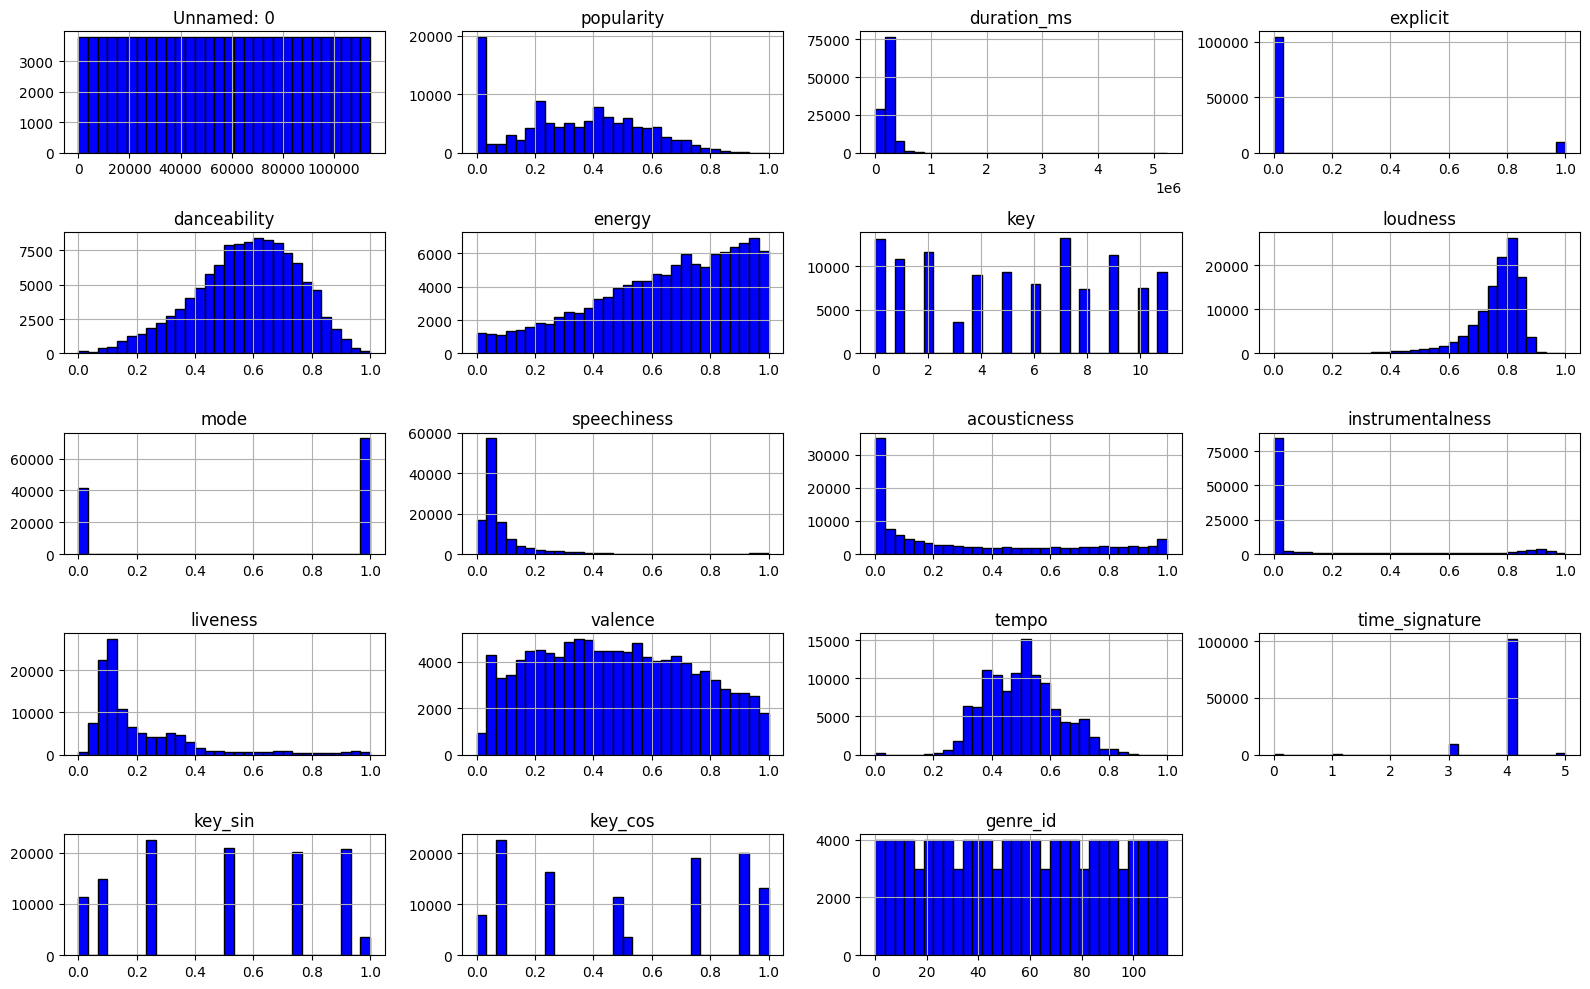

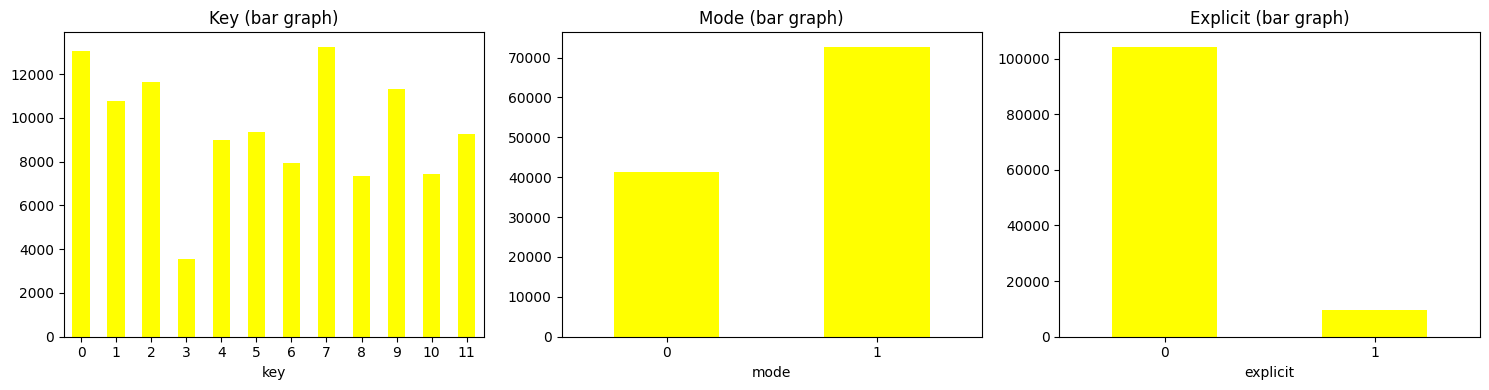

In [13]:
plot_for_all(data)

In [14]:
import torch.nn.functional as F
import torch.optim as optim


In [15]:
dataloader = DataLoader(dataset,batch_size=128,shuffle=True)
len(dataloader)

891

In [16]:
class ArcStreamAutoencoder(nn.Module):
    def __init__(self,nun_genre,input_dim=14,genre_embed_dim=8,latent_dim=32):
        super(ArcStreamAutoencoder,self).__init__()
        self.genre_embed = nn.Embedding(nun_genre,genre_embed_dim)

        self.encoder = nn.Sequential(
            nn.Linear(input_dim + genre_embed_dim,128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(0.2),
            nn.Linear(128,64),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,latent_dim)
        )

        self.decoder = nn.Sequential(
            nn.Linear(latent_dim+genre_embed_dim,64),
            nn.LeakyReLU(0.2),
            nn.Linear(64,128),
            nn.LeakyReLU(0.2),
            nn.Linear(128,input_dim),
            nn.Sigmoid()
        )

    def forward(self,x,genre_ids):
        g=self.genre_embed(genre_ids)
        h=torch.cat([x,g],dim=-1)
        z=self.encoder(h)

        recon_input = torch.cat([z,g],dim=-1)
        recon_x = self.decoder(recon_input)

        return recon_x,z
    
    def get_latent(self,x,genre_ids):
        with torch.no_grad():
            self.eval()
            g= self.genre_embed(genre_ids)
            h=torch.cat([x,g],dim=-1)
            return self.encoder(h)

In [17]:
def train_autoencoder(model,dataloader,epochs=30,learning_rate = 1e-3):
    print("strating training")
    optimizer = optim.Adam(model.parameters(),lr=learning_rate)
    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_features,batch_genre in dataloader:
            optimizer.zero_grad()

            recon_batch,_=model(batch_features,batch_genre)
            loss= F.mse_loss(recon_batch,batch_features,reduction='mean')

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        if (epoch+1)%5==0:
            avg_loss = total_loss/len(dataloader)
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

        print("training finished")

        return model
    
num_unique_genres = len(torch.unique(x_genre))

# 2. Initialize the model
ae_model = ArcStreamAutoencoder(nun_genre=num_unique_genres, input_dim=14)

# 3. Train it! (This might take a minute or two depending on your machine)
trained_ae = train_autoencoder(ae_model, dataloader, epochs=30)

# --- SAVE THE FINAL DATABASE ---

print("Extracting final coordinates and saving database...")
# Get coordinates for the entire dataset
all_coordinates = trained_ae.get_latent(x_feature, x_genre)

# Convert to a DataFrame
z_cols = [f'z_{i}' for i in range(32)]
z_df = pd.DataFrame(all_coordinates.numpy(), columns=z_cols)

# Stick the new coordinates next to your original data
final_db_df = pd.concat([data.reset_index(drop=True), z_df], axis=1)

# Save to CSV
final_db_df.to_csv('arc_stream_ae_database.csv', index=False)
print("✅ Saved 'arc_stream_ae_database.csv'!")

# Save the model weights just in case
torch.save(trained_ae.state_dict(), 'autoencoder_weights.pth')

strating training
training finished
Extracting final coordinates and saving database...
✅ Saved 'arc_stream_ae_database.csv'!


In [18]:
df_db = pd.read_csv('arc_stream_ae_database.csv')
df_db.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,z_22,z_23,z_24,z_25,z_26,z_27,z_28,z_29,z_30,z_31
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,0.73,230666,0,0.686294,0.4610,...,1.032832,-0.138315,0.514204,-0.236142,-2.140629,0.691422,0.347684,0.160968,-0.784070,-1.504398
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,0.55,149610,0,0.426396,0.1660,...,1.997016,-0.681107,-1.522948,0.697943,-1.409392,-0.712019,0.071503,-1.397240,-0.551517,0.083989
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,0.57,210826,0,0.444670,0.3590,...,2.038757,0.287620,-1.282199,0.473803,-2.131103,-1.093257,0.148605,-0.657980,-0.720240,0.204221
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,0.71,201933,0,0.270051,0.0596,...,0.941085,-0.934812,-0.433473,0.848696,-1.989391,-1.263117,0.873911,-2.420720,0.261448,1.203370
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,0.82,198853,0,0.627411,0.4430,...,1.298973,0.453924,-0.933472,1.503353,-1.203850,-0.306211,0.014405,-0.541052,-0.578910,1.402182


In [19]:
df_db = df_db.sort_values(by = ['genre_id','energy']).reset_index(drop=True)

In [27]:
def create_lstm_sequence(df,seq_length=5):
    print("generating sliding window sequences")
    z_cols = [f'z_{i}'for i in range(32)]
    z_data = df[z_cols].values
    energy_data = df['energy'].values

    X,Y =[],[]

    for i in range(len(df)-seq_length):
        current_sequence = z_data[i:i+seq_length]
        target_energy = energy_data[i+1:i+seq_length+1]
        target_energy_expanded = np.expand_dims(target_energy,axis=1)
        combined_x = np.concatenate((current_sequence,target_energy_expanded),axis=1)
        actual_next_y = z_data[i+1:i+seq_length+1]
        X.append(combined_x)
        Y.append(actual_next_y)

    return torch.tensor(np.array(X),dtype=torch.float32), torch.tensor(np.array(Y),dtype=torch.float32)

# X_seq,Y_seq = create_lstm_sequence(df_db,seq_length=5)

In [28]:
X_seq,Y_seq = create_lstm_sequence(df_db,seq_length=5)

class SequenceDataset(Dataset):
    def __init__(self,X,Y):
        self.X=X
        self.Y=Y

    def __len__(self):
        return len(self.X)
    
    def __getitem__(self,idx):
        return self.X[idx],self.Y[idx]
    
lstm_loader = DataLoader(SequenceDataset(X_seq,Y_seq),batch_size=64,shuffle=True)
print(f"created {len(X_seq)} training sequences ready for the lstm")

generating sliding window sequences
created 113995 training sequences ready for the lstm


In [46]:
class ArcNavigatorLSTM(nn.Module):
    def __init__(self,input_dim=33,hidden_dim=128,latent_dim=32,num_layers=2):
        super(ArcNavigatorLSTM,self).__init__()

        self.hidden_dim = hidden_dim
        self.nam_layers = num_layers

        self.lstm = nn.LSTM(
            input_size = input_dim,
            hidden_size = hidden_dim,
            num_layers = num_layers,
            batch_first = True,
            dropout = 0.2
        )

        self.fc_z = nn.Linear(hidden_dim, latent_dim)
        self.fc_energy = nn.Linear(hidden_dim, 1)  # NEW: Predict energy

    def forward(self, x, hidden=None):
        lstm_out, hidden = self.lstm(x, hidden)

        predicted_z = self.fc_z(lstm_out)
        predicted_energy = torch.sigmoid(self.fc_energy(lstm_out))  # Normalize to [0,1]
        return predicted_z, predicted_energy, hidden

In [47]:
def train_autoencoder(model,dataloader,epochs=50,learning_rate = 1e-3):
    print("starting training")
    optimizer = optim.Adam(model.parameters(),lr = learning_rate)
    criterion = nn.MSELoss()

    model.train()

    for epoch in range(epochs):
        total_loss = 0

        for batch_x,batch_y in dataloader:
            optimizer.zero_grad()
            predicted_z, predicted_energy, _ = model(batch_x)
            
            # Extract actual energy from batch_x (last column)
            actual_energy = batch_x[:, :, -1:]  # Shape: (batch, seq, 1)
            
            # Compute losses
            z_loss = criterion(predicted_z, batch_y)
            energy_loss = criterion(predicted_energy, actual_energy)
            
            # Combined loss: weight energy prediction equally important
            loss = z_loss + energy_loss
            
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            
        avg_loss = total_loss/len(dataloader)
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
        
    print("training finished")
    return model


navigator_lstm = ArcNavigatorLSTM(input_dim=33,hidden_dim=128,latent_dim=32,num_layers=2)
trained_lstm = train_autoencoder(navigator_lstm,lstm_loader,epochs=30,learning_rate=1e-3)
torch.save(trained_lstm.state_dict(),'navigator_lstm_weights.pth')
print("✅ Saved 'navigator_lstm_weights.pth'!")

starting training
Epoch [1/30], Loss: 0.8586
Epoch [2/30], Loss: 0.8232
Epoch [3/30], Loss: 0.8126
Epoch [4/30], Loss: 0.8046
Epoch [5/30], Loss: 0.7983
Epoch [6/30], Loss: 0.7932
Epoch [7/30], Loss: 0.7886
Epoch [8/30], Loss: 0.7842
Epoch [9/30], Loss: 0.7803
Epoch [10/30], Loss: 0.7765
Epoch [11/30], Loss: 0.7731
Epoch [12/30], Loss: 0.7697
Epoch [13/30], Loss: 0.7667
Epoch [14/30], Loss: 0.7637
Epoch [15/30], Loss: 0.7614
Epoch [16/30], Loss: 0.7585
Epoch [17/30], Loss: 0.7564
Epoch [18/30], Loss: 0.7541
Epoch [19/30], Loss: 0.7521
Epoch [20/30], Loss: 0.7502
Epoch [21/30], Loss: 0.7484
Epoch [22/30], Loss: 0.7468
Epoch [23/30], Loss: 0.7450
Epoch [24/30], Loss: 0.7437
Epoch [25/30], Loss: 0.7426
Epoch [26/30], Loss: 0.7411
Epoch [27/30], Loss: 0.7398
Epoch [28/30], Loss: 0.7385
Epoch [29/30], Loss: 0.7376
Epoch [30/30], Loss: 0.7365
training finished
✅ Saved 'navigator_lstm_weights.pth'!


In [48]:
def lstm_testing(start_idx,target_energy,model,df,seq_length=5):

    input_indices = list(range(start_idx,start_idx+seq_length))
    z_cols = [f'z_{i}'for i in range(32)]
    current_z = df.loc[input_indices,z_cols].values
    energy_array = np.full((seq_length,1),target_energy)
    combined_input = np.concatenate((current_z,energy_array),axis=1)

    lstm_input = torch.tensor(combined_input,dtype=torch.float32).unsqueeze(0)

    model.eval()
    with torch.no_grad():
        predicted_z, predicted_energy, _ = model(lstm_input)
        next_z = predicted_z[0,-1,:].unsqueeze(0)
        next_energy = predicted_energy[0,-1].item()  # Get predicted energy

    # Find closest match in latent space
    all_z_tensors = torch.tensor(df[z_cols].values,dtype=torch.float32)
    distances = torch.cdist(next_z,all_z_tensors)
    closest_idx = torch.argmin(distances).item()

    output_name = df.loc[closest_idx,'track_name']
    output_artist = df.loc[closest_idx,'artists']
    output_genre = df.loc[closest_idx,'track_genre']
    output_energy = df.loc[closest_idx,'energy']
    
    print(f"Predicted next track: '{output_name}' by {output_artist} (Genre: {output_genre})")
    print(f"Model predicted energy: {next_energy:.2f} | Actual track energy: {output_energy:.2f}")

    diff = abs(target_energy - output_energy)
    predicted_diff = abs(next_energy - output_energy)  # Compare predicted energy too
    
    if diff < 0.15:
        print(f"✅ Great match! Energy difference: {diff:.2f}")
    elif predicted_diff < 0.15:
        print(f"✅ Model prediction accurate! Predicted vs actual energy diff: {predicted_diff:.2f}")
    else:
        print(f"Energy difference of {diff:.2f}. Not a perfect match, but could still be interesting!")

test_start_idx = 4000
test_target_energy = 0.85
lstm_testing(test_start_idx,test_target_energy,trained_lstm,df_db,seq_length=5)

Predicted next track: 'White Kross (Bonus track)' by Napalm Death (Genre: grindcore)
Model predicted energy: 0.72 | Actual track energy: 0.74
✅ Great match! Energy difference: 0.11
